In [ ]:
import dd
from dd.cudd import BDD
import tqdm
import matplotlib.pyplot as plt

def ROBDD_div(n: int, order: str = "grouped") -> (BDD, dd.cudd.Function):
    bdd = BDD()
    bdd.configure(reordering=False)
    
    x_vars = [f'x{i}' for i in range(n)]
    y_vars = [f'y{i}' for i in range(n)]
    z_vars = [f'z{i}' for i in range(n)]
    list = []
    if order == "grouped":
        list = x_vars + y_vars + z_vars
    else:
        for i in range(n):
            list.append(x_vars[i])
            list.append(y_vars[i])
        list += z_vars
    
    bdd.declare(*list)
    
    formula = bdd.false
    
    for x in tqdm.tqdm(range(2**n)):
        for y in range(1, 2**n):
            z = x // y
            r = x % y

            some_dict = {
                **{f'x{i}': bool((x >> i) & 1) for i in range(n)},
                **{f'y{i}': bool((y >> i) & 1) for i in range(n)},
                **{f'z{i}': bool((z >> i) & 1) for i in range(n)}
            }
            term = bdd.cube(some_dict)
            formula |= term
    
    return (bdd, formula)


def calc_div(f, x: int, y: int, n: int) -> int:
    
    substitution = {
                **{f'x{i}': bool((x >> i) & 1) for i in range(n)},
                **{f'y{i}': bool((y >> i) & 1) for i in range(n)}
            }
    bdd = f.bdd
    
    result = bdd.let(substitution, f)

    z_val = 0
    for i in range(n):
        temp = bdd.let({f'z{i}': False}, result)
        if temp != bdd.false:
            result = temp
        else:
            z_val |= (1 << i)
            result = bdd.let({f'z{i}': True}, result)
    return z_val

def test_division(n):
    bdd, f = ROBDD_div(n)
    bdd2, g = ROBDD_div(n, "interleaved")
    success = True
    
    for x in tqdm.tqdm(range(2**n)):
        for y in range(1, 2**n): 
            expected = x // y
            computed = calc_div(f, x, y, n)
            if(expected != computed):
                success = False
                print(f"Error x={x}, y={y}: expected {expected}, got {computed}")
    for x in tqdm.tqdm(range(2**n)):
        for y in range(1, 2**n): 
            expected = x // y
            computed = calc_div(g, x, y, n)
            if(expected != computed):
                success = False
                print(f"Error x={x}, y={y}: expected {expected}, got {computed}")
    if(success):
        print("Tests success")
        

def res_in_I_division(a: int, b: int, n: int) -> dd.cudd.Function:
    bdd, f = ROBDD_div(n)

    max_val = (1 << n) - 1
    a = max(0, min(a, max_val))
    b = max(0, min(b, max_val))

    condition = bdd.false
    for z_val in range(a, b + 1):
        temp = bdd.cube({f'z{i}': bool((z_val >> i) & 1) for i in range(n)})
        condition |= temp

    result = bdd.exist([f'z{i}' for i in range(n)], f & condition)
    return result

from collections import defaultdict, deque

def robdd_width(bdd, f):

    visited = set()

    level_nodes = defaultdict(set)

    q = deque([f])

    while len(q):

        node = q.popleft()

        if node in visited:
            continue

        visited.add(node)

        if node == bdd.true or node == bdd.false:
            continue

        level = bdd.level_of_var(node.var)

        level_nodes[level].add(node)

        q.append(node.low)
        q.append(node.high)

    return max(len(v) for v in level_nodes.values())

import math
import numpy as np

def analyze_size(max_n):
    x_data = []
    y_data_nodes = []
    y_data_width = []
    for n in range(1, max_n):
        bdd, f = ROBDD_div(n)
        bdd2, g = ROBDD_div(n, "interleaved")
        #print(bdd.vars)
        stats = bdd.statistics()
        print(stats)
        print(f"Bits {n} groped:")
        print(f"  Nodes: {len(bdd)}")
        print(f"  Max width: {robdd_width(bdd, f)}")
        print(f"Bits {n} interleaved:")
        print(f"  Nodes: {len(bdd2)}")
        print(f"  Max width: {robdd_width(bdd2, g)}")
        x_data.append(n)
        y_data_nodes.append(math.log2(len(bdd)))
        y_data_width.append(math.log2(robdd_width(bdd, f)))
    plt.plot(x_data, y_data_nodes)
    plt.plot(x_data, y_data_width)
    plt.grid()
    plt.show()

def test_har(a, b, n):
    har = res_in_I_division(a, b, n)
    bdd, f = ROBDD_div(n)

    success = True
    for x in tqdm.tqdm(range(2**n)):
        for y in range(1, 2**n):
            substitution = {
                    **{f'x{i}': bool((x >> i) & 1) for i in range(n)},
                    **{f'y{i}': bool((y >> i) & 1) for i in range(n)}
                }
            bdd = har.bdd
            
            result = bdd.let(substitution, har)
            if(result == bdd.true):
                expected_z = calc_div(f, x, y, n)
                if not(expected_z >= a and expected_z <= b):
                    success = False
                    print(f"Error x={x} // y={y} does not lie in interval [a={a}, b={b}]")
    if(success):
        print("Haracteristics function is correct")

100%|██████████| 2/2 [00:00<00:00, 25811.10it/s]
/tmp/ipykernel_12762/1672755063.py:126: UserWarning: Changed in `dd` version 0.5.7: In the `dict` returned by the method `dd.cudd.BDD.statistics`, the value of the key `'mem'` has changed to bytes (from 10**6 bytes).
  stats = bdd.statistics()


{'n_vars': 3, 'n_nodes': 10, 'peak_nodes': 1022, 'peak_live_nodes': 12, 'reordering_time': 0.0, 'n_reorderings': 0, 'mem': 16814536.0, 'unique_size': 1024, 'unique_used_fraction': 0.0107421875, 'expected_unique_used_fraction': 0.011639027351305176, 'cache_size': 262144, 'cache_used_fraction': 1.52587890625e-05, 'cache_lookups': 2.0, 'cache_hits': 0.0, 'cache_insertions': 4.0, 'cache_collisions': 0.0, 'cache_deletions': 0.0}
Bits 1:
  Nodes: 5
  Max width: 2


100%|██████████| 4/4 [00:00<00:00, 45343.83it/s]


{'n_vars': 6, 'n_nodes': 26, 'peak_nodes': 1022, 'peak_live_nodes': 33, 'reordering_time': 0.0, 'n_reorderings': 0, 'mem': 16814536.0, 'unique_size': 1792, 'unique_used_fraction': 0.04185267857142857, 'expected_unique_used_fraction': 0.0437062185452356, 'cache_size': 262144, 'cache_used_fraction': 0.000164031982421875, 'cache_lookups': 30.0, 'cache_hits': 18.0, 'cache_insertions': 46.0, 'cache_collisions': 3.0, 'cache_deletions': 0.0}
Bits 2:
  Nodes: 18
  Max width: 5


100%|██████████| 8/8 [00:00<00:00, 38836.15it/s]


...

{'n_vars': 21, 'n_nodes': 2289, 'peak_nodes': 22484, 'peak_live_nodes': 2375, 'reordering_time': 0.0, 'n_reorderings': 0, 'mem': 17575272.0, 'unique_size': 9472, 'unique_used_fraction': 0.6772592905405406, 'expected_unique_used_fraction': 0.6806850841779019, 'cache_size': 262144, 'cache_used_fraction': 0.15726470947265625, 'cache_lookups': 199094.0, 'cache_hits': 195499.0, 'cache_insertions': 142442.0, 'cache_collisions': 93188.0, 'cache_deletions': 46060.0}
Bits 7:
  Nodes: 2266
  Max width: 406


100%|██████████| 256/256 [00:00<00:00, 627.15it/s]


{'n_vars': 24, 'n_nodes': 5676, 'peak_nodes': 43946, 'peak_live_nodes': 5801, 'reordering_time': 0.0, 'n_reorderings': 0, 'mem': 18318024.0, 'unique_size': 17152, 'unique_used_fraction': 0.7701725746268657, 'expected_unique_used_fraction': 0.7678935486742167, 'cache_size': 262144, 'cache_used_fraction': 0.4649505615234375, 'cache_lookups': 938981.0, 'cache_hits': 919752.0, 'cache_insertions': 637474.0, 'cache_collisions': 404476.0, 'cache_deletions': 226935.0}
Bits 8:
  Nodes: 5650
  Max width: 979


100%|██████████| 512/512 [00:01<00:00, 306.74it/s]


{'n_vars': 27, 'n_nodes': 13913, 'peak_nodes': 58254, 'peak_live_nodes': 14114, 'reordering_time': 0.0, 'n_reorderings': 0, 'mem': 18794760.0, 'unique_size': 20224, 'unique_used_fraction': 0.657090585443038, 'expected_unique_used_fraction': 0.6536575895858018, 'cache_size': 262144, 'cache_used_fraction': 0.9198951721191406, 'cache_lookups': 4321770.0, 'cache_hits': 4227326.0, 'cache_insertions': 2814209.0, 'cache_collisions': 1743684.0, 'cache_deletions': 1063954.0}
Bits 9:
  Nodes: 13884
  Max width: 2302


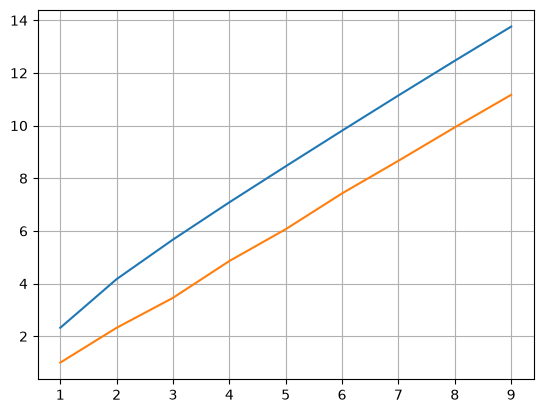

In [2]:
n = 10
analyze_size(n)

In [3]:
n = 10
test_division(n)

100%|██████████| 1024/1024 [00:14<00:00, 69.88it/s]

Tests success


In [4]:
n = 10
a = 1
b = 2
test_har(a, b, n)

100%|██████████| 1024/1024 [00:10<00:00, 93.51it/s]

Haracteristics function is correct
